# KMRF Model - Single Asset Test Notebook

This notebook demonstrates two modes:
1. **TRAIN MODE**: Train a new model from scratch (with optional Boruta feature selection)
2. **LOAD MODE**: Load a previously saved model (skip training and feature selection entirely)

The save/load functionality preserves:
- Trained Random Forest model
- Selected features (if Boruta was used)
- Train/validation/test data splits
- All model metadata

### Imports

In [148]:
# %pip install -r requirements.txt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import kmrf as kmrf

%matplotlib inline

### Helper: List Available Saved Models

Run this cell to see what models are available to load:

In [149]:
from pathlib import Path

classification_dir = 'adapted'  # Specify the classification directory here
asset_class_dir = 'us_equity'    # Specify the asset class directory here

saved_models_dir = Path(f'saved_models/KMRF/{classification_dir}_labels/{asset_class_dir}')

if saved_models_dir.exists():
    saved_models_list = list(saved_models_dir.glob('*.pkl'))

    if saved_models_list:
        saved_models_list = sorted(saved_models_list)
        print(f"Available saved models in '{saved_models_dir}':\n")
        for i, model_path in enumerate(saved_models_list):
            print(f" index = {i}: {model_path.name}")
    else:
        print(f"No saved models found in '{saved_models_dir}'. Train a model first!")

Available saved models in 'saved_models/KMRF/adapted_labels/us_equity':

 index = 0: KMRF_Consumer-Discretionary-Select-Sector-SPDR_20190101_boruta.pkl
 index = 1: KMRF_Consumer-Staples-Select-Sector-SPDR_20190101_boruta.pkl
 index = 2: KMRF_Energy-Select-Sector-SPDR_20190101_boruta.pkl
 index = 3: KMRF_Financial-Select-Sector-SPDR_20190101_boruta.pkl
 index = 4: KMRF_Health-Care-Select-Sector-SPDR_20190101_boruta.pkl
 index = 5: KMRF_Industrial-Select-Sector-SPDR_20190101_boruta.pkl
 index = 6: KMRF_Invesco-QQQ-Trust_20190101_boruta.pkl
 index = 7: KMRF_Materials-Select-Sector-SPDR_20190101_boruta.pkl
 index = 8: KMRF_SPDR-S&P-500-ETF_20190101_boruta.pkl
 index = 9: KMRF_Technology-Select-Sector-SPDR_20190101_boruta.pkl
 index = 10: KMRF_Utilities-Select-Sector-SPDR_20190101_boruta.pkl
 index = 11: KMRF_iShares-Russell-2000-ETF_20190101_boruta.pkl
 index = 12: KMRF_iShares-S&P-500-Growth-ETF_20190101_boruta.pkl
 index = 13: KMRF_iShares-S&P-500-Value-ETF_20190101_boruta.pkl


## *** Configuration ***

Choose either:
- **TRAIN MODE**: Train a new model with optional Boruta feature selection
- **LOAD MODE**: Load a previously saved model (skips training and feature selection)

In [ ]:
# ============================================================================
# CONFIGURATION: Choose Training Mode or Load Existing Model
# ============================================================================

# MODE: Set to True to load existing model, False to train from scratch
LOAD_EXISTING_MODEL = True

if LOAD_EXISTING_MODEL: # specify the model path
    saved_model_index = 9  # Change this index to load a different saved model from the directory shown above
    MODEL_PATH = saved_models_list[saved_model_index]

else: # configure training parameters
    OVERWRITE_SAVED_MODEL = False  # Whether to overwrite existing saved model with same name
    
    asset_name = 'Invesco QQQ Trust'
    asset_class = 'us_equity'  # us_equity, int_equity, us_treasury, commodity

    classification_type = 'adapted'  # 'original' (4 regimes) or 'adapted' (3 regimes)
    boruta_feature_selection = True  # Whether to use Boruta feature selection (slow but effective)

    # Training/validation/test split dates
    end_date = '20190101'  # Data up to this date for training
    validation_start = '2019-04-01'
    validation_end = '2019-09-30'
    test_start = '2020-01-01'

## 1. Load or Initialize KMRF Model

This section handles both modes:
- **LOAD MODE**: Loads a saved model with all trained parameters
- **TRAIN MODE**: Initializes a new model for training

In [151]:
if LOAD_EXISTING_MODEL:
    # ========== LOAD MODE ==========
    print("="*80)
    print("LOAD MODE: Loading previously trained model")
    print("="*80)
    
    kmrf_model = kmrf.KMRF.load_model(MODEL_PATH)
    
    print("\n✓ Model loaded successfully!")
    print("  You can skip directly to prediction (Section 6)")
    
else:
    # ========== TRAIN MODE ==========
    print("="*80)
    print("TRAIN MODE: Initializing new model for training")
    print("="*80)
    
    # Initialize KMRF for this specific asset
    kmrf_model = kmrf.KMRF(
        asset_name=asset_name,
        asset_class=asset_class,
        end_date=end_date,
        use_ready_data=True,
        validation_start=validation_start,
        validation_end=validation_end,
        test_start=test_start,
        random_seed=1010,
        classification_type=classification_type
    )
    
    print(f"\n{kmrf_model}")

LOAD MODE: Loading previously trained model

LOADING SAVED KMRF MODEL
Model path: saved_models/KMRF/adapted_labels/us_equity/KMRF_Technology-Select-Sector-SPDR_20190101_boruta.pkl
KMRF model initialized
  Asset: Technology Select Sector SPDR
  Asset class: us_equity
  Classification type: adapted
  End date: 20190101
  Using pre-computed features: True
  Data path: data/ready/us_equity.csv
  KAMA+MSR model directory: saved_models/KAMA_MSR/us_equity/20190101
  Validation period: 2019-04-01 00:00:00 to 2019-09-30 00:00:00
  Test start: 2020-01-01 00:00:00
  Random seed: 1010

✓ Model loaded successfully
  Asset: Technology Select Sector SPDR
  Asset class: us_equity
  Classification type: adapted
  Training end date: 20190101
  Features: 107
  Boruta used: True

  Restored data splits:
    Training samples: 5037 (with labels)
    Validation samples: 127 (features only)
    Test samples: 1463 (features only)

  Model is ready for predictions!
  You can now call predict() without retrainin

## 2. Load Data and Features

**Note**: Skip this section if LOAD_EXISTING_MODEL = True (already loaded with model)

In [152]:
if not LOAD_EXISTING_MODEL:
    # Load data for this asset
    data = kmrf_model.load_data()
    
    # Extract pre-computed features
    features = kmrf_model.get_features()
    
    print(f"\nData shape: {data.shape}")
    print(f"Features shape: {features.shape}")
    print(f"Date range: {features.index[0]} to {features.index[-1]}")
else:
    print("Skipping data loading - using loaded model data")

Skipping data loading - using loaded model data


## 3. Load KAMA+MSR Labels

**Note**: Skip this section if LOAD_EXISTING_MODEL = True

In [153]:
if not LOAD_EXISTING_MODEL:
    # Load original 4-regime labels from saved models
    original_labels = kmrf_model.load_kama_msr_labels()
else:
    print("Skipping label loading - using loaded model")

Skipping label loading - using loaded model


In [154]:
if not LOAD_EXISTING_MODEL and classification_type == 'adapted':
    # Adapt to 3-class KMRF labels
    adapted_labels = kmrf_model.adapt_regime_labels()
elif LOAD_EXISTING_MODEL:
    print("Skipping label adaptation - using loaded model")
else:
    print("Using original 4-regime labels")

Skipping label adaptation - using loaded model


## 4. Prepare Training Data with Train/Val/Test Split

**Note**: Skip this section if LOAD_EXISTING_MODEL = True (data already split in loaded model)

In [155]:
if not LOAD_EXISTING_MODEL:
    # Prepare training data with automatic splitting
    # Set select_features=True to use Boruta (may take time)
    X_train, y_train = kmrf_model.prepare_training_data(
        include_macro=True,
        select_features=boruta_feature_selection,
        split_data=True  # Automatically creates train/val/test splits
    )
    
    print(f"\n✓ Training data prepared")
    print(f"  X_train shape: {X_train.shape}")
    print(f"  y_train shape: {y_train.shape}")
else:
    print("Skipping data preparation - using loaded model's data splits")
    print(f"  X_train shape: {kmrf_model.X_train.shape}")
    print(f"  y_train shape: {kmrf_model.y_train.shape}")
    if kmrf_model.X_test is not None:
        print(f"  X_test shape: {kmrf_model.X_test.shape}")

Skipping data preparation - using loaded model's data splits
  X_train shape: (5037, 107)
  y_train shape: (5037,)
  X_test shape: (1463, 107)


## 5. Train Random Forest Model

**Note**: Skip this section if LOAD_EXISTING_MODEL = True (model already trained)

In [156]:
if not LOAD_EXISTING_MODEL:
    print("\n" + "="*80)
    print("TRAINING RANDOM FOREST MODEL")
    print("="*80)
    
    # Train the Random Forest classifier
    kmrf_model.fit(kmrf_model.X_train, kmrf_model.y_train)
    
    print("\n✓ Model training complete!")
    
    # Save the trained model
    print("\n" + "="*80)
    print("SAVING TRAINED MODEL")
    print("="*80)
    
    model_path = kmrf_model.save_model(boruta_used=boruta_feature_selection)
    
    print(f"\n✓ Model saved to: {model_path}")
    print(f"  You can load this model later to skip retraining:")
    print(f"  kmrf_model = kmrf.KMRF.load_model('{model_path}')")
    
else:
    print("\nSkipping model training - using loaded model")
    print("  Model is already trained and ready for predictions")


Skipping model training - using loaded model
  Model is already trained and ready for predictions


## 6. Generate Predictions on Test Set

This works for both LOAD and TRAIN modes!

In [157]:
# Generate predictions for the test set
print("\n" + "="*80)
print("GENERATING PREDICTIONS ON TEST SET")
print("="*80)

# Generate predictions for the test set
test_predictions = kmrf_model.predict(kmrf_model.X_test, return_proba=True)

print(f"\nTest predictions generated:")
print(f"  Shape: {test_predictions.shape}")
print(f"  Date range: {test_predictions.index[0].date()} to {test_predictions.index[-1].date()}")

# Show sample predictions
print(f"\nSample predictions (first 10 rows):")
print(test_predictions.head(10).round(4))

# Get predicted regimes (highest probability class)
predicted_regimes = kmrf_model.predict(kmrf_model.X_test, return_proba=False)
predicted_regimes_series = pd.Series(predicted_regimes, index=test_predictions.index)

if kmrf_model.classification_type == 'original':
    regime_names = {
        0: 'LV Bullish',
        1: 'LV Bearish',
        2: 'HV Bullish',
        3: 'HV Bearish'
    }
else: # adapted
    regime_names = {
        -1: 'Bearish',
         0: 'Other',
         1: 'Bullish'
    }
print(f"\nPredicted regime distribution:")
for regime, name in regime_names.items():
    count = (predicted_regimes_series == regime).sum()
    pct = (count / len(predicted_regimes_series)) * 100
    print(f"  {name:>8} ({regime:>2}): {count:>5} ({pct:>5.1f}%)")


GENERATING PREDICTIONS ON TEST SET

Generating predictions...
  Input shape: (1463, 107)
  Using pre-selected features: 107
✓ Generated probability predictions: (1463, 3)

Test predictions generated:
  Shape: (1463, 3)
  Date range: 2020-01-02 to 2025-10-24

Sample predictions (first 10 rows):
            P(Bearish)  P(Other)  P(Bullish)
date                                        
2020-01-02      0.0024    0.0097      0.9879
2020-01-03      0.0072    0.0222      0.9706
2020-01-06      0.0136    0.0356      0.9508
2020-01-07      0.0024    0.0102      0.9874
2020-01-08      0.0024    0.0102      0.9874
2020-01-09      0.0031    0.0102      0.9867
2020-01-10      0.0024    0.0102      0.9874
2020-01-13      0.0024    0.0102      0.9874
2020-01-14      0.0024    0.0097      0.9879
2020-01-15      0.0026    0.0102      0.9872

Generating predictions...
  Input shape: (1463, 107)
  Using pre-selected features: 107
✓ Generated class predictions: 1463

Predicted regime distribution:
   Bear

## 7. Visualize Predicted Regimes

In [158]:
# Getting raw price data
us_equity_symbol_names = {
    # BOND ETFS
    'BIL': 'SPDR Bloomberg 1-3 Month T-Bill ETF',
    'SHY': 'iShares 1-3 Year Treasury Bond ETF',
    'IEF': 'iShares 7-10 Year Treasury Bond ETF',
    # MAJOR INDICES
    '^GSPC': 'S&P 500',
    '^IXIC': 'Nasdaq Composite',
    '^NDX': 'Nasdaq 100',
    '^RUT': 'Russell 2000',
    '^DJI': 'Dow Jones Industrial Average',
    '^RUI': 'Russell 1000',
    '^RUA': 'Russell 3000',
    
    # MAIN BROAD MARKET ETFS
    'SPY': 'SPDR S&P 500 ETF',
    'VOO': 'Vanguard S&P 500 ETF',
    'RSP': 'Invesco S&P 500 Equal Weight ETF',
    'IVV': 'iShares Core S&P 500 ETF',
    'QQQ': 'Invesco QQQ Trust',
    'QQQM': 'Invesco Nasdaq 100 ETF',
    'ONEQ': 'Fidelity Nasdaq Composite Index ETF',
    'IWM': 'iShares Russell 2000 ETF',
    'IWB': 'iShares Russell 1000 ETF',
    'IWV': 'iShares Russell 3000 ETF',
    'DIA': 'SPDR Dow Jones Industrial Average ETF',
    'VTI': 'Vanguard Total Stock Market ETF',
    
    # S&P 500 SECTOR ETFS (SELECT SECTOR SPDRS)
    'XLE': 'Energy Select Sector SPDR',
    'XLF': 'Financial Select Sector SPDR',
    'XLU': 'Utilities Select Sector SPDR',
    'XLI': 'Industrial Select Sector SPDR',
    'XLV': 'Health Care Select Sector SPDR',
    'XLK': 'Technology Select Sector SPDR',
    'XLB': 'Materials Select Sector SPDR',
    'XLY': 'Consumer Discretionary Select Sector SPDR',
    'XLP': 'Consumer Staples Select Sector SPDR',
    'XLRE': 'Real Estate Select Sector SPDR',
    'XLC': 'Communication Services Select Sector SPDR',
    
    # GROWTH ETFs
    'IVW': 'iShares S&P 500 Growth ETF',
    'VONG': 'Vanguard Russell 1000 Growth ETF',
    'IWF': 'iShares Russell 1000 Growth ETF',
    'IWO': 'iShares Russell 2000 Growth ETF',
    'VUG': 'Vanguard Growth ETF',
    'SPYG': 'SPDR Portfolio S&P 500 Growth ETF',
    
    # VALUE ETFs
    'IVE': 'iShares S&P 500 Value ETF',
    'VONV': 'Vanguard Russell 1000 Value ETF',
    'IWD': 'iShares Russell 1000 Value ETF',
    'IWN': 'iShares Russell 2000 Value ETF',
    'VTV': 'Vanguard Value ETF',
    'SPYV': 'SPDR Portfolio S&P 500 Value ETF',
    
    # SIZE ETFs
    'IWR': 'iShares Russell Mid-Cap ETF',
    'IWC': 'iShares Micro-Cap ETF',
    'IJH': 'iShares Core S&P Mid-Cap ETF',
    'IJR': 'iShares Core S&P Small-Cap ETF',
    'MDY': 'SPDR S&P MidCap 400 ETF',
    'SLY': 'SPDR S&P 600 Small Cap ETF',
    'VO': 'Vanguard Mid-Cap ETF',
    'VB': 'Vanguard Small-Cap ETF',
    'SCHA': 'Schwab U.S. Small-Cap ETF',
    'SCHM': 'Schwab U.S. Mid-Cap ETF',
    'VTWO': 'Vanguard Russell 2000 ETF',
    'VTHR': 'Vanguard Russell 3000 ETF',
    'THRK': 'iShares Russell 3000 ETF',
    'SPSM': 'SPDR Portfolio S&P 600 Small Cap ETF',
    'SMLF': 'iShares Small-Cap US Equity Factor ETF',
    
    # NASDAQ SPECIFIC
    'QTEC': 'First Trust Nasdaq-100 Technology Sector Index Fund',
    'QQEW': 'First Trust Nasdaq-100 Equal Weighted Index Fund',
    'QQQG': 'Pacer Nasdaq 100 Top 50 Cash Cows Dividend Growth ETF',
    'QQQV': 'Pacer Nasdaq 100 Top 50 Value ETF',
    
    # DIVIDEND/QUALITY
    'SCHD': 'Schwab U.S. Dividend Equity ETF',
    'VYM': 'Vanguard High Dividend Yield ETF',
    'DVY': 'iShares Select Dividend ETF',
    'QUAL': 'iShares MSCI USA Quality Factor ETF',
    'USMV': 'iShares MSCI USA Min Vol Factor ETF',
    
    # EQUAL WEIGHT
    'EWSC': 'Invesco S&P SmallCap 600 Equal Weight ETF',
    'EWMC': 'Invesco S&P MidCap 400 Equal Weight ETF',
}
int_equity_symbol_names = {
    'VXUS': 'Vanguard Total International Stock ETF',
    'VEA': 'Vanguard FTSE Developed Markets ETF',
    'VWO': 'Vanguard FTSE Emerging Markets ETF',
    'VGK': 'Vanguard FTSE Europe ETF',
    'VPL': 'Vanguard FTSE Pacific ETF',
    'FXI': 'iShares China Large-Cap ETF',
    'EWJ': 'iShares MSCI Japan ETF',
    'INDA': 'iShares MSCI India ETF',
}
etf_symbol_name_dict = {**us_equity_symbol_names, **int_equity_symbol_names}

fmp_comm = pd.read_csv('data/inputs/fmp_commodity_list.csv')
comm_symbol_name_dict = fmp_comm.set_index('symbol')['name'].to_dict()
comm_symbol_name_dict.update({'Nickel': 'Nickel'})

if kmrf_model.asset_class != 'commodity':
    raw_price_data = pd.read_csv('data/processed/us_equity_all_data.csv', index_col=0, header=[0, 1], parse_dates=True)
    raw_price_data.index = pd.to_datetime(raw_price_data.index)
    raw_price_data.rename(columns=etf_symbol_name_dict, level=0, inplace=True)
else:
    raw_price_data = pd.read_csv('data/processed/commodity_data.csv', index_col=0, header=[0, 1], parse_dates=True)
    raw_price_data.index = pd.to_datetime(raw_price_data.index)
    raw_price_data.rename(columns=comm_symbol_name_dict, level=0, inplace=True)

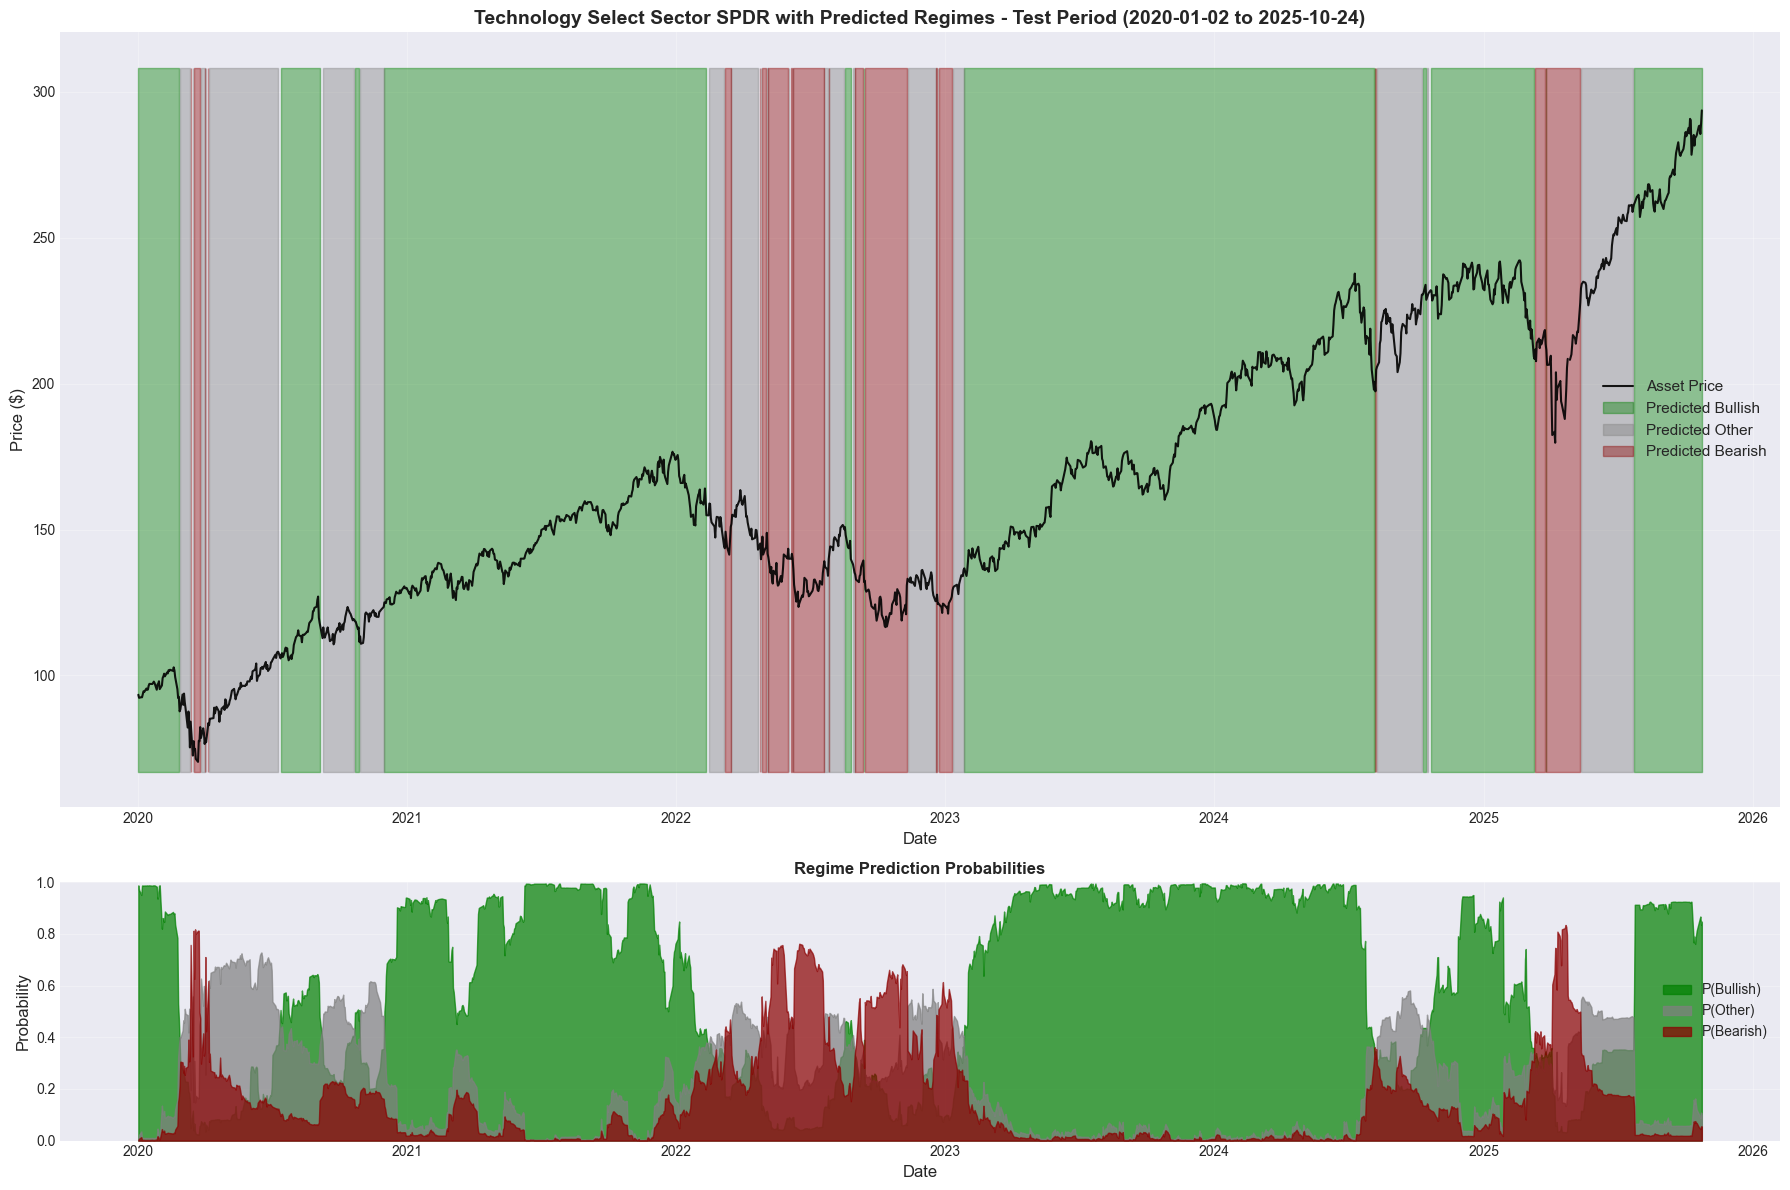


✓ Regime visualization complete!

PREDICTION SUMMARY FOR Technology Select Sector SPDR
Test Period: 2020-01-02 to 2025-10-24
Total Trading Days: 1463

Price Performance:
  Start Price (open on 2020-01-02): $92.50
  End Price (close on 2025-10-24): $293.58
  Buy and Hold Return: 217.38%

Regime Prediction Statistics:
   Bearish: 182 days ( 12.4%) | Avg Prob: 0.159
     Other: 338 days ( 23.1%) | Avg Prob: 0.225
   Bullish: 943 days ( 64.5%) | Avg Prob: 0.616

High Confidence Predictions (>70%): 811 days (55.4%)

KMRF MODEL TRAINING AND PREDICTION COMPLETE


In [159]:
# Visualize regime predictions over test period

# Get raw price data for test period
asset_price_test = raw_price_data[[(kmrf_model.asset_name, 'open'), (kmrf_model.asset_name, 'close')]]
asset_price_test = asset_price_test.loc[kmrf_model.X_test.index[0]:kmrf_model.X_test.index[-1]]
asset_price_test.columns = ['open', 'close']

if asset_price_test is not None:
    # Create comprehensive visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), height_ratios=[3, 1])
    
    # === Price Plot with Regime Overlays ===
    # Plot asset price
    ax1.plot(asset_price_test.index, asset_price_test['close'], color='black', linewidth=1.5, 
             alpha=0.9, label='Asset Price', zorder=3)

    # Define colors and labels for regimes based on classification type
    if kmrf_model.classification_type == 'original':
        colors = {0: 'green', 1: 'lightblue', 2: 'yellow', 3: 'darkred'}
        labels_dict = {0: 'LV_Bull', 1: 'LV_Bear', 2: 'HV_Bull', 3: 'HV_Bear'}
    else:
        colors = {1: 'green', 0: 'grey', -1: 'darkred'}
        labels_dict = {1: 'Bullish', 0: 'Other', -1: 'Bearish'}
    
    
    # Shade regime periods
    for regime in labels_dict:
        mask = predicted_regimes_series == regime
        if mask.any():
            ax1.fill_between(
                asset_price_test.index,
                asset_price_test['close'].min() * 0.95,
                asset_price_test['close'].max() * 1.05,
                where=mask,
                alpha=0.4,
                color=colors[regime],
                label=f'Predicted {labels_dict[regime]}',
                zorder=1
            )
    
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Price ($)', fontsize=12)
    ax1.set_title(f'{kmrf_model.asset_name} with Predicted Regimes - Test Period ({test_predictions.index[0].date()} to {test_predictions.index[-1].date()})', 
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=11)
    ax1.grid(True, alpha=0.3, zorder=2)
    
    # === Regime Probabilities ===
    # Plot regime probabilities
    # Handle different regime types based on classification
    if kmrf_model.classification_type == 'original':
        # Original 4-regime system
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(LV_Bull)'],
                     alpha=0.7, color='green', label='P(LV Bullish)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(LV_Bear)'],
                     alpha=0.7, color='lightblue', label='P(LV Bearish)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(HV_Bull)'],
                     alpha=0.7, color='yellow', label='P(HV Bullish)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(HV_Bear)'],
                     alpha=0.7, color='darkred', label='P(HV Bearish)')
    else:
        # Adapted 3-regime system
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(Bullish)'],
                     alpha=0.7, color='green', label='P(Bullish)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(Other)'],
                     alpha=0.7, color='gray', label='P(Other)')
        ax2.fill_between(test_predictions.index, 0, test_predictions['P(Bearish)'],
                     alpha=0.7, color='darkred', label='P(Bearish)')
    
    ax2.set_xlabel('Date', fontsize=12)
    ax2.set_ylabel('Probability', fontsize=12)
    ax2.set_title('Regime Prediction Probabilities', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, 1)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Regime visualization complete!")
    
    # === Summary Statistics ===
    print(f"\n" + "="*60)
    print(f"PREDICTION SUMMARY FOR {kmrf_model.asset_name}")
    print(f"="*60)
    print(f"Test Period: {test_predictions.index[0].date()} to {test_predictions.index[-1].date()}")
    print(f"Total Trading Days: {len(test_predictions)}")
    
    # Price performance during test period
    price_start = asset_price_test['open'].iloc[0]
    price_end = asset_price_test['close'].iloc[-1]
    total_return = (price_end - price_start) / price_start * 100
    
    print(f"\nPrice Performance:")
    print(f"  Start Price (open on {asset_price_test.index[0].date()}): ${price_start:.2f}")
    print(f"  End Price (close on {asset_price_test.index[-1].date()}): ${price_end:.2f}")
    print(f"  Buy and Hold Return: {total_return:.2f}%")
    
    # Regime statistics
    print(f"\nRegime Prediction Statistics:")
    for regime, name in regime_names.items():
        count = (predicted_regimes_series == regime).sum()
        pct = (count / len(predicted_regimes_series)) * 100
        avg_prob = test_predictions['P(' + labels_dict[regime] + ')'].mean()
        print(f"  {name:>8}: {count:>3} days ({pct:>5.1f}%) | Avg Prob: {avg_prob:.3f}")
    
    # High confidence predictions
    high_confidence = test_predictions.max(axis=1) > 0.7
    print(f"\nHigh Confidence Predictions (>70%): {high_confidence.sum()} days ({high_confidence.mean()*100:.1f}%)")
    
    # print(f"\nNote: According to the contrarian strategy:")
    # print(f"  - High P(Bullish) → SHORT signal (overbought)")
    # print(f"  - High P(Bearish) → LONG signal (oversold)")
    # print(f"  - High P(Other) → CLOSE position")

else:
    print(f"Error: Could not find {kmrf_model.asset_name} price data for visualization")

print("\n" + "="*80)
print("KMRF MODEL TRAINING AND PREDICTION COMPLETE")
print("="*80)

## Saving Model

In [ ]:
if LOAD_EXISTING_MODEL == False and OVERWRITE_SAVED_MODEL == True:
    kmrf_model.save_model(boruta_used=boruta_feature_selection)  # Saves with auto-generated name